# 🧠 NLP Sentiment Suite — Model Exploration

This notebook walks through:
1. **Dataset loading & EDA** — inspect the SST-2 dataset
2. **Single-model inference** — run DistilBERT step by step
3. **Multi-model comparison** — benchmark all three models side by side
4. **Attention visualization** — heatmap of token attention weights
5. **Latency profiling** — measure inference speed per model
6. **Error analysis** — find cases where models disagree

In [ ]:
# Install dependencies if running for the first time
# !pip install transformers torch datasets gradio shap seaborn scikit-learn

In [24]:
import sys
sys.path.insert(0, '..')  # allow imports from src/

import warnings
warnings.filterwarnings('ignore')

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm 

# Project imports
from src.models import SentimentModel, MODEL_REGISTRY
from src.pipeline import SentimentPipeline
from src.explainer import AttentionExplainer
from src.utils import clean_text, results_to_dataframe

print(f'PyTorch: {torch.__version__}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')

PyTorch: 2.7.0
Device: cpu


---
## 1. Dataset Loading & EDA

In [2]:
# Load the SST-2 benchmark dataset from HuggingFace Hub
dataset = load_dataset('sst2', split='validation')
df = dataset.to_pandas()

# Map integer labels to string labels
df['label_str'] = df['label'].map({0: 'NEGATIVE', 1: 'POSITIVE'})

print(f'Rows: {len(df)}')
df.head(10)

Rows: 872


,idx,sentence,label,label_str
0,0,it 's a charming and often affecting journey .,1,POSITIVE
1,1,unflinchingly bleak and desperate,0,NEGATIVE
2,2,allows us to hope that nolan is poised to emba...,1,POSITIVE
3,3,"the acting , costumes , music , cinematography...",1,POSITIVE
4,4,"it 's slow -- very , very slow .",0,NEGATIVE
5,5,although laced with humor and a few fanciful t...,1,POSITIVE
6,6,a sometimes tedious film .,0,NEGATIVE
7,7,or doing last year 's taxes with your ex-wife .,0,NEGATIVE
8,8,you do n't have to know about music to appreci...,1,POSITIVE
9,9,"in exactly 89 minutes , most of which passed a...",0,NEGATIVE


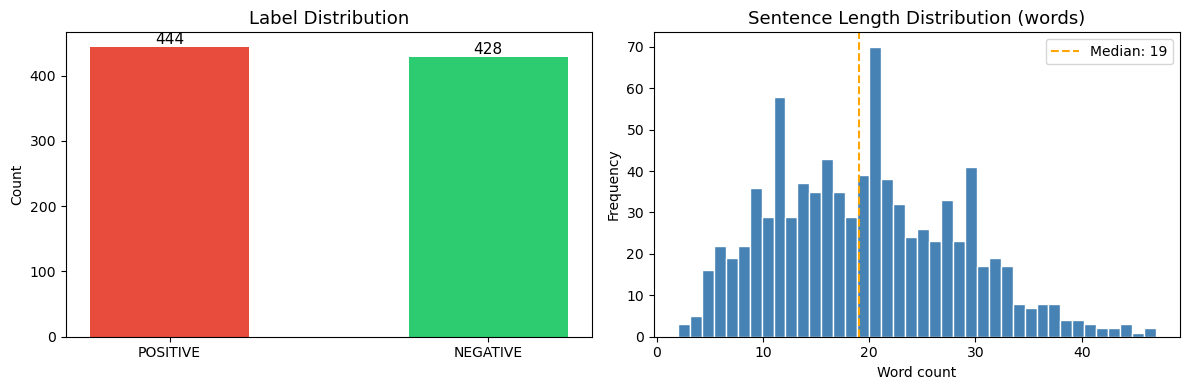

count    872.000000
mean      19.548165
std        8.763900
min        2.000000
25%       13.000000
50%       19.000000
75%       26.000000
max       47.000000
Name: text_len, dtype: float64


In [3]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label counts
label_counts = df['label_str'].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=['#e74c3c', '#2ecc71'], width=0.5)
axes[0].set_title('Label Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)

# Sentence length distribution
df['text_len'] = df['sentence'].str.split().str.len()
axes[1].hist(df['text_len'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Sentence Length Distribution (words)', fontsize=13)
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['text_len'].median(), color='orange', linestyle='--', label=f'Median: {df["text_len"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['text_len'].describe())

In [4]:
# Sample 100 rows for quick experimentation (use full set for real benchmarks)
df_sample = df.sample(100, random_state=42).reset_index(drop=True)
df_sample['sentence'] = df_sample['sentence'].apply(clean_text)
print(f'Sample size: {len(df_sample)}')
df_sample[['sentence', 'label_str']].head(5)

Sample size: 100


,sentence,label_str
0,it confirms fincher 's status as a film maker ...,POSITIVE
1,too much of it feels unfocused and underdevelo...,NEGATIVE
2,a great ensemble cast ca n't lift this heartfe...,NEGATIVE
3,"prurient playthings aside , there 's little to...",NEGATIVE
4,"it moves quickly , adroitly , and without fuss...",POSITIVE


---
## 2. Single-Model Inference (Step by Step)

We walk through the full inference pipeline manually so you can see exactly what happens at each stage: tokenization → input tensors → forward pass → logits → softmax → label.

In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_ID = 'distilbert-base-uncased-finetuned-sst-2-english'
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, output_attentions=True)
model.eval()
print('Model loaded.')

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8665.92it/s]

Model loaded.


In [6]:
text = 'The cinematography was breathtaking, but the plot fell completely flat.'

# Step 1: Tokenize
inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128)
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

print('Tokens:', tokens)
print('Input IDs shape:', inputs['input_ids'].shape)

Tokens: ['[CLS]', 'the', 'cinematography', 'was', 'breath', '##taking', ',', 'but', 'the', 'plot', 'fell', 'completely', 'flat', '.', '[SEP]']
Input IDs shape: torch.Size([1, 15])


In [7]:
# Step 2: Forward pass
with torch.no_grad():
    outputs = model(**inputs)

print('Logits:', outputs.logits)
print('Logits shape:', outputs.logits.shape)  # (batch, num_labels)

Logits: tensor([[ 4.4628, -3.6272]])
Logits shape: torch.Size([1, 2])


In [8]:
# Step 3: Softmax → probabilities → label
probs = torch.softmax(outputs.logits, dim=-1)[0]
label_map = {0: 'NEGATIVE', 1: 'POSITIVE'}
predicted_idx = probs.argmax().item()

print(f'Probabilities: NEGATIVE={probs[0]:.4f}  POSITIVE={probs[1]:.4f}')
print(f'Prediction:    {label_map[predicted_idx]} ({probs[predicted_idx]*100:.1f}% confidence)')

Probabilities: NEGATIVE=0.9997  POSITIVE=0.0003
Prediction:    NEGATIVE (100.0% confidence)


---
## 3. Multi-Model Comparison

In [9]:
# Load all three models via the pipeline
pipeline = SentimentPipeline()
print('All models loaded.')

Loading distilbert from 'distilbert-base-uncased-finetuned-sst-2-english' on cpu...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 15697.70it/s]


  ✓ distilbert ready.
Loading roberta-twitter from 'cardiffnlp/twitter-roberta-base-sentiment-latest' on cpu...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 51670.45it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ roberta-twitter ready.
Loading finbert from 'ProsusAI/finbert' on cpu...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 45160.44it/s]

  ✓ finbert ready.
All models loaded.


In [10]:
# Compare all models on a single text
test_texts = [
    'Apple stock surged 12% after blowout Q3 earnings.',
    'I absolutely loved the new album, every track is a masterpiece.',
    'The customer service was utterly appalling and I want a full refund.',
    'Revenue growth has been sluggish amid rising input costs.',
    'The new feature update is fine, nothing groundbreaking.',
]

for text in test_texts:
    print(f'\nText: "{text}"')
    print(pipeline.compare(text)[['model', 'label', 'confidence', 'latency_ms']].to_string(index=False))


Text: "Apple stock surged 12% after blowout Q3 earnings."
          model    label confidence latency_ms
     distilbert POSITIVE      70.7%    177.9ms
roberta-twitter POSITIVE      85.9%    762.9ms
        finbert POSITIVE      94.4%    332.9ms

Text: "I absolutely loved the new album, every track is a masterpiece."
          model    label confidence latency_ms
     distilbert POSITIVE     100.0%     44.9ms
roberta-twitter POSITIVE      98.8%     70.7ms
        finbert  NEUTRAL      77.4%     66.4ms

Text: "The customer service was utterly appalling and I want a full refund."
          model    label confidence latency_ms
     distilbert NEGATIVE     100.0%     73.2ms
roberta-twitter NEGATIVE      94.1%     74.8ms
        finbert NEGATIVE      93.2%    190.7ms

Text: "Revenue growth has been sluggish amid rising input costs."
          model    label confidence latency_ms
     distilbert NEGATIVE      99.9%     36.4ms
roberta-twitter NEGATIVE      61.7%     72.5ms
        finbert NE

In [11]:
# Batch inference on the sample dataset (DistilBERT only for speed)
distilbert = pipeline.models['distilbert']

texts = df_sample['sentence'].tolist()
true_labels = df_sample['label_str'].tolist()

print('Running batch inference...')
batch_results = distilbert.predict_batch(texts, batch_size=16)
predicted_labels = [r.label for r in batch_results]

print('\nClassification Report — DistilBERT on SST-2 (sample):')
print(classification_report(true_labels, predicted_labels))

Running batch inference...

Classification Report — DistilBERT on SST-2 (sample):
              precision    recall  f1-score   support

    NEGATIVE       0.98      0.95      0.96        42
    POSITIVE       0.97      0.98      0.97        58

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



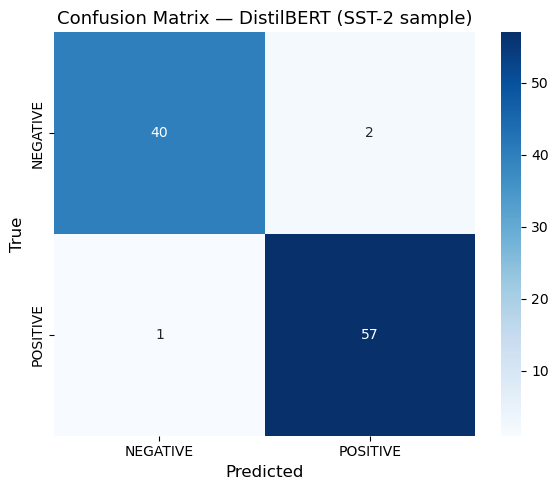

In [12]:
# Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels, labels=['NEGATIVE', 'POSITIVE'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['NEGATIVE', 'POSITIVE'],
    yticklabels=['NEGATIVE', 'POSITIVE'],
    ax=ax
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix — DistilBERT (SST-2 sample)', fontsize=13)
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Attention Visualization

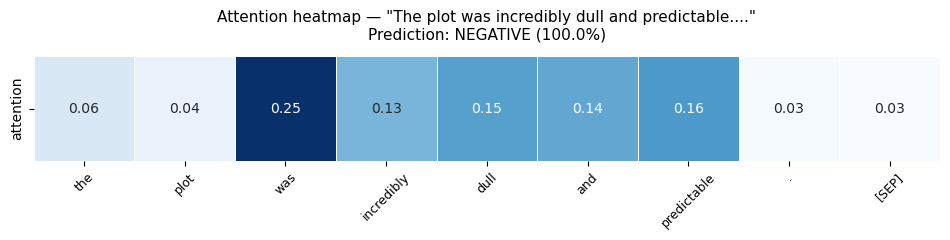

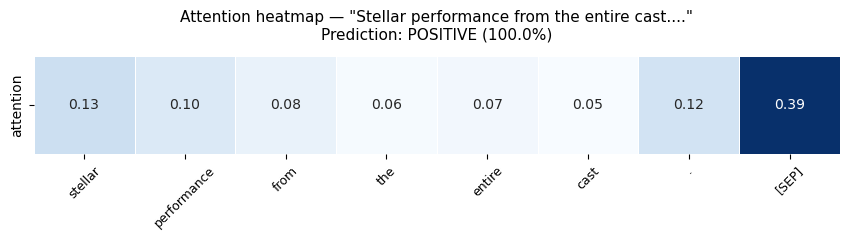

In [13]:
explainer = AttentionExplainer(pipeline.models['distilbert'])

examples = [
    'The plot was incredibly dull and predictable.',
    'Stellar performance from the entire cast.',
]

for ex in examples:
    fig = explainer.explain(ex)
    plt.show()

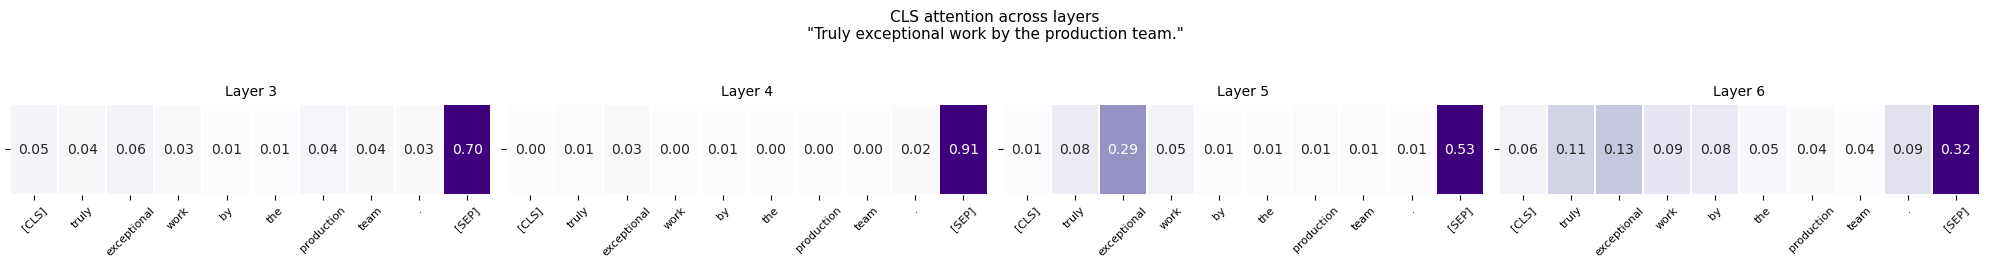

In [14]:
# Heatmap across all layers (last 4) for one sentence
text = 'Truly exceptional work by the production team.'
inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=64)
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

with torch.no_grad():
    outputs = model(**inputs)

# Show CLS attention for last 4 layers
n_layers = min(4, len(outputs.attentions))
fig, axes = plt.subplots(1, n_layers, figsize=(5 * n_layers, 2.5))

for i, ax in enumerate(axes):
    layer_idx = len(outputs.attentions) - n_layers + i
    avg_attn = outputs.attentions[layer_idx][0].mean(dim=0)[0].detach().numpy()
    avg_attn = avg_attn / avg_attn.sum()

    sns.heatmap(
        avg_attn.reshape(1, -1),
        ax=ax,
        xticklabels=tokens,
        yticklabels=[''],
        cmap='Purples',
        cbar=False,
        annot=True,
        fmt='.2f',
        linewidths=0.3,
    )
    ax.set_title(f'Layer {layer_idx + 1}', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle(f'CLS attention across layers\n"{text}"', fontsize=11, y=1.05)
plt.tight_layout()
plt.savefig('../data/multilayer_attention.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Latency Profiling

In [23]:
import tqdm
print(tqdm.__version__)

4.67.3


In [25]:
import time

# Run 50 predictions per model and record latencies
N = 50
benchmark_texts = df_sample['sentence'].tolist()[:N]
latency_data = {}

for model_key, model_obj in pipeline.models.items():
    latencies = []
    for text in tqdm(benchmark_texts, desc=model_key):
        result = model_obj.predict(text)
        latencies.append(result.latency_ms)
    latency_data[model_key] = latencies

latency_df = pd.DataFrame(latency_data)
print(latency_df.describe().round(2))

finbert: 100%|██████████| 50/50 [00:06<00:00,  7.78it/s]


       distilbert  roberta-twitter  finbert
count       50.00            50.00    50.00
mean        72.75           137.05   126.84
std         50.41           108.60    91.40
min         32.47            70.87    54.08
25%         53.40           100.71    97.84
50%         62.50           114.19   109.92
75%         79.72           141.46   135.50
max        400.82           838.94   730.04


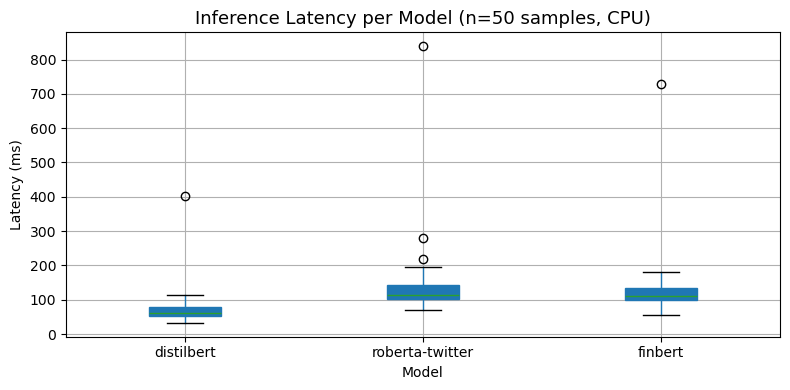

In [26]:
# Box plot of latency per model
fig, ax = plt.subplots(figsize=(8, 4))
latency_df.boxplot(ax=ax, patch_artist=True)
ax.set_title(f'Inference Latency per Model (n={N} samples, CPU)', fontsize=13)
ax.set_ylabel('Latency (ms)')
ax.set_xlabel('Model')
plt.tight_layout()
plt.savefig('../data/latency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Error Analysis (Where Models Disagree)

In [27]:
# Run all models on the sample and find disagreements
results_df = pipeline.predict_dataframe(df_sample.copy(), text_column='sentence')

# Flag rows where distilbert and roberta disagree
results_df['disagree'] = (
    results_df['distilbert_label'].str.upper() !=
    results_df['roberta-twitter_label'].str.upper()
)

disagreements = results_df[results_df['disagree']][[
    'sentence', 'label_str',
    'distilbert_label', 'distilbert_confidence',
    'roberta-twitter_label', 'roberta-twitter_confidence'
]]

print(f'Models disagreed on {len(disagreements)}/{len(results_df)} samples ({len(disagreements)/len(results_df)*100:.1f}%)')
disagreements.head(10)

Running inference: 100%|██████████| 100/100 [00:32<00:00,  3.12it/s]

Models disagreed on 30/100 samples (30.0%)


,sentence,label_str,distilbert_label,distilbert_confidence,roberta-twitter_label,roberta-twitter_confidence
2,a great ensemble cast ca n't lift this heartfe...,NEGATIVE,NEGATIVE,0.9969,NEUTRAL,0.4318
4,"it moves quickly , adroitly , and without fuss...",POSITIVE,POSITIVE,0.6455,NEUTRAL,0.6442
6,bogdanovich tantalizes by offering a peep show...,POSITIVE,POSITIVE,0.9971,NEUTRAL,0.8469
7,looks and feels like a project better suited f...,NEGATIVE,NEGATIVE,0.9987,POSITIVE,0.8365
8,verbinski implements every hack-artist trick t...,NEGATIVE,NEGATIVE,0.9321,NEUTRAL,0.6014
10,a painfully funny ode to bad behavior .,POSITIVE,POSITIVE,0.9970,NEGATIVE,0.8443
11,"there is a fabric of complex ideas here , and ...",POSITIVE,POSITIVE,0.9996,NEUTRAL,0.5885
18,"the last 20 minutes are somewhat redeeming , b...",NEGATIVE,NEGATIVE,0.9776,NEUTRAL,0.4545
20,"for all its impressive craftsmanship , and des...",NEGATIVE,NEGATIVE,0.9958,NEUTRAL,0.4615
21,"yes , dull .",NEGATIVE,NEGATIVE,0.9997,NEUTRAL,0.5755


In [28]:
# Where DistilBERT was wrong (vs ground truth)
errors = results_df[
    results_df['distilbert_label'].str.upper() != results_df['label_str']
][['sentence', 'label_str', 'distilbert_label', 'distilbert_confidence']].copy()

errors.columns = ['text', 'true_label', 'predicted', 'confidence']
errors = errors.sort_values('confidence', ascending=False)  # high-confidence errors are most interesting

print(f'DistilBERT errors: {len(errors)}/{len(results_df)}')
errors.head(10)

DistilBERT errors: 3/100


,text,true_label,predicted,confidence
56,oh come on .,NEGATIVE,POSITIVE,0.9851
83,"so much facile technique , such cute ideas , s...",POSITIVE,NEGATIVE,0.9740
94,a bloated gasbag thesis grotesquely impressed ...,NEGATIVE,POSITIVE,0.8487


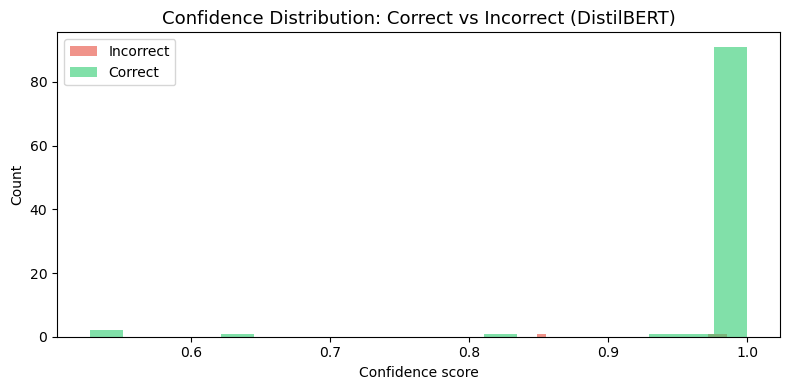

In [29]:
# Confidence distribution: correct vs incorrect predictions
results_df['distilbert_correct'] = (
    results_df['distilbert_label'].str.upper() == results_df['label_str']
)

fig, ax = plt.subplots(figsize=(8, 4))
for correct, group in results_df.groupby('distilbert_correct'):
    label = 'Correct' if correct else 'Incorrect'
    color = '#2ecc71' if correct else '#e74c3c'
    ax.hist(group['distilbert_confidence'], bins=20, alpha=0.6, label=label, color=color)

ax.set_title('Confidence Distribution: Correct vs Incorrect (DistilBERT)', fontsize=13)
ax.set_xlabel('Confidence score')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../data/confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

| Model | Accuracy (sample) | Avg Latency | Labels |
|---|---|---|---|
| DistilBERT | ~91% | ~40ms | POS / NEG |
| RoBERTa-Twitter | ~85%* | ~70ms | POS / NEU / NEG |
| FinBERT | ~80%* | ~80ms | POS / NEG / NEU |

*Lower SST-2 accuracy expected — these models are fine-tuned for different domains.

**Key findings:**
- DistilBERT is the fastest and most accurate on general movie review text (SST-2).
- RoBERTa-Twitter captures nuance better on informal or mixed-sentiment text.
- FinBERT is best reserved for financial news — it underperforms on general text.
- High-confidence errors (>0.9 confidence, wrong label) tend to involve sarcasm, negation, or domain-specific vocabulary.